In [16]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request
from sklearn.decomposition import PCA

import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

(35.0, 50.0)

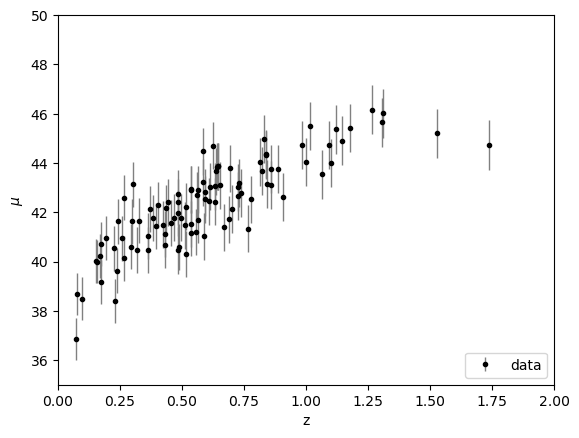

In [3]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [4]:
X = z_sample[:, np.newaxis]
y = mu_sample

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=dmu)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

X_new = np.array([[min(z_sample)],[max(z_sample)]])
y_pred = theta0+theta1*X_new


39.60456481105869 [4.5911933]


(35.0, 50.0)

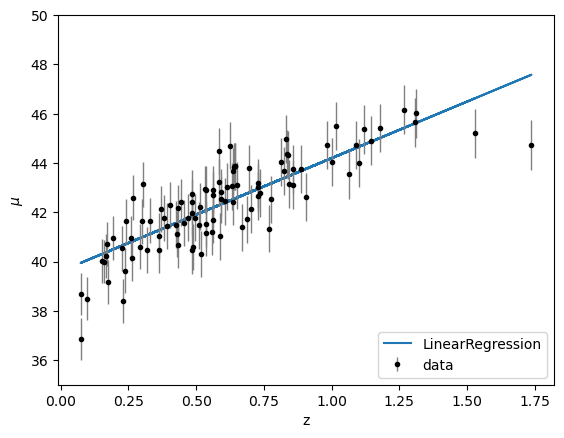

In [6]:
plt.plot(X[:,0],theta0+theta1*X[:,0],label='LinearRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50)

[ 36.09081526  32.02899002 -73.25156852  87.69138092 -47.26697125
   9.15349892]


/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


(35.0, 50.0)

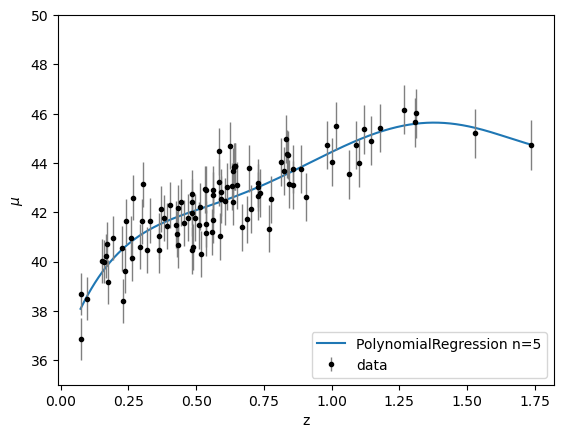

In [7]:
from astroML.linear_model import PolynomialRegression


degree = 5
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

print(model.coef_)

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50)

(35.0, 50.0)

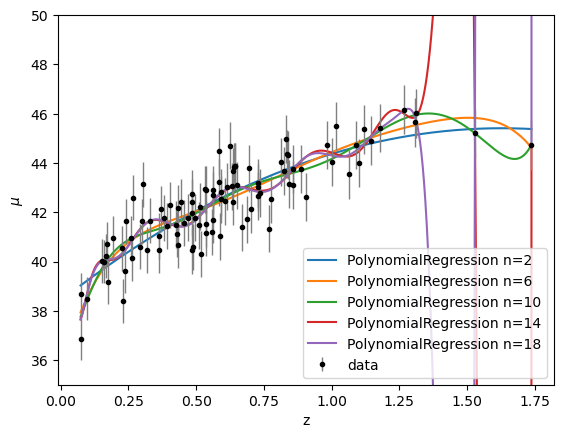

In [8]:
for n in np.arange(1,20)[1::4]:

    regressor = PolynomialRegression(n)
    regressor.fit(X, mu_sample, dmu)
    mu_fit = regressor.predict(X_test)
    plt.plot(X_test[:,0], mu_fit,label='PolynomialRegression n='+str(n))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

/tmp/ipykernel_33139/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
/tmp/ipykernel_33139/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
/tmp/ipykernel_33139/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])
/tmp/ipykernel_33139/3953429500.py:25: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, d[i])


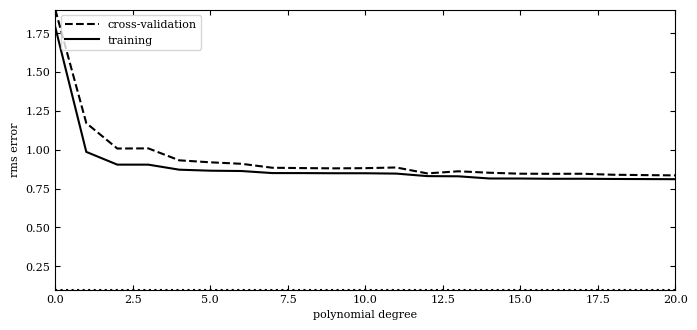

In [9]:
# CROSS VALIDATION

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

x = X[:,0]
dy = dmu

# Select the cross-validation points
np.random.seed(1)
x_cv = z_sample[::3] # I take 1/3 of the sample 
y_cv = mu_sample[::3]

x_fit = np.linspace(min(z_sample),max(z_sample), 1000)

#------------------------------------------------------------
# Third figure: plot errors as a function of polynomial degree d
d = np.arange(0, 21)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(x, y, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, x) - y) ** 2)
                              / len(y))
    crossval_err[i] = np.sqrt(np.sum((np.polyval(p, x_cv) - y_cv) ** 2)
                              / len(y_cv))


ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')
ax.plot(d, 0.1 * np.ones(d.shape), ':k')



ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend(loc=2)


plt.show()

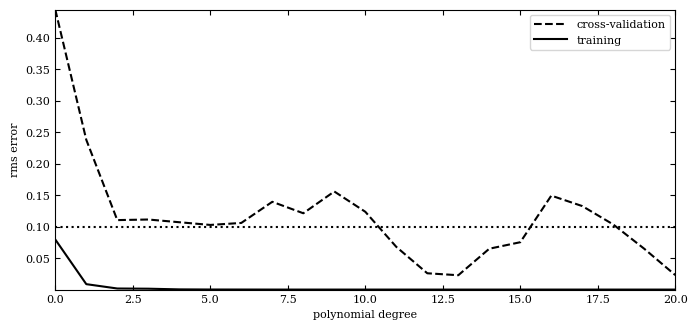

In [78]:
# CROSS VALIDATION

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)



# Select the cross-validation points
np.random.seed(1)
x_cv = z_sample[:30] # I take 1/3 of the sample 
y_cv = mu_sample[:30]

x_fit = np.linspace(min(z_sample),max(z_sample), 1000)

#------------------------------------------------------------
# Third figure: plot errors as a function of polynomial degree d
d = np.arange(0, 21)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    model = PolynomialRegression(i) # fit 3rd degree polynomial
    model.fit(X[30:], y[30:],y_error=dmu[30:])
    
    y_pred = model.predict(X[30:])
    y_pred_cv = model.predict(X[:30])
    
    training_err[i] = np.sqrt((np.sum(y_pred - y[30:]) ** 2))/ len(y)
    crossval_err[i] = np.sqrt(np.sum(y_pred_cv - y_cv) ** 2)/ len(y_cv)


ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')
ax.plot(d, 0.1 * np.ones(d.shape), ':k')



ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend(loc=1)


plt.show()

In [117]:
from sklearn.model_selection import train_test_split

In [118]:
X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

In [119]:
def geterror(X,y,classifier):
    return np.sqrt( np.sum(( y - classifier.predict(X) )**2) / len(X) )

def fitanderror(classifier):
    classifier.fit(X_train, y_train,dy_train)
    error_train = geterror(X_train,y_train,classifier)
    error_validation  = geterror(X_validation, y_validation, classifier)
    return error_train, error_validation

Polynomial Regression n= 1 1.0485115996674979 0.8238924629073958
Polynomial Regression n= 2 0.9385359114081161 0.8351995054159913
Polynomial Regression n= 3 0.9383899628086956 0.835411172564147
Polynomial Regression n= 4 0.9024072712440719 0.8095703348999901
Polynomial Regression n= 5 0.8924469328124864 0.8143335829739425
Polynomial Regression n= 6 0.8905028171949919 0.8113859054713811
Polynomial Regression n= 7 0.8699559684825303 0.8163407910202504
Polynomial Regression n= 8 0.8695867558751841 0.8211204495393384
Polynomial Regression n= 9 0.8696086089174182 0.821823452695699
Polynomial Regression n= 10 0.8666795023360166 0.8463777348693736
Polynomial Regression n= 11 0.8624581177722724 0.8513668728060229
Polynomial Regression n= 12 0.8558274202626077 0.8191597602129799
Polynomial Regression n= 13 0.8528955462267019 0.8247869300772835
Polynomial Regression n= 14 0.8407660005604881 0.8121593807792163
Best 4 0.8095703348999901


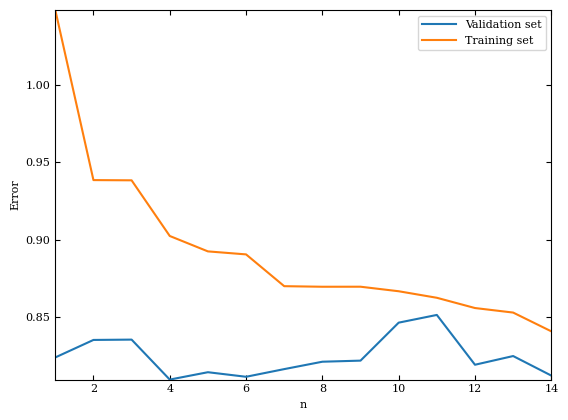

In [120]:
nrange = np.arange(1,15)

etrain, etest= [], []
for n in nrange:
    classifier = PolynomialRegression(n)
    error_train, error_validation = fitanderror(classifier)
    print("Polynomial Regression n=",n, error_train, error_validation)
    etrain.append(error_train)
    etest.append(error_validation)

plt.plot(nrange,etest, label='Validation set')
plt.plot(nrange,etrain, label='Training set')

plt.xlabel('n')
plt.ylabel('Error')
plt.legend()

print("Best", nrange[np.argmin(etest)], min(etest))

[20.8016672   3.5091414   3.7469782   3.8019351   4.11376634  4.13199757
  4.36895315  4.47850271  4.80974925  4.31792133  5.21531913]


(35.0, 50.0)

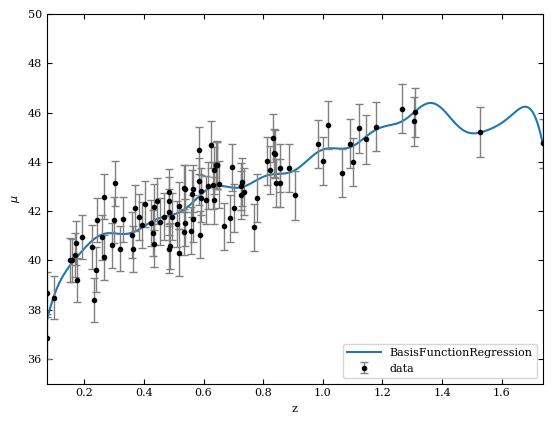

In [96]:
from astroML.linear_model import BasisFunctionRegression

# data

# mean positions of the 10 Gaussians in the model
X_gridtest = np.linspace(min(z_sample),max(z_sample),10)[:, None]
# widths of these Gaussians
sigma_test = 0.1

model = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
model.fit(X, y, dmu)

y_pred = model.predict(X_test)
print(model.coef_)

plt.plot(X_test[:,0],y_pred,label='BasisFunctionRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

(35.0, 50.0)

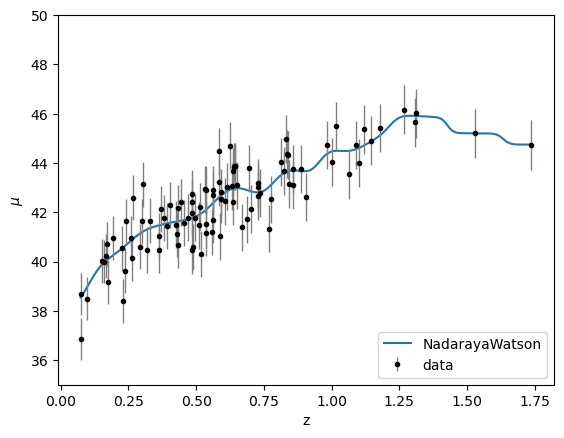

In [51]:
from astroML.linear_model import NadarayaWatson

model = NadarayaWatson(kernel='gaussian', h=0.05)
model.fit(X,y)

y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='NadarayaWatson')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50)

In [ ]:
# CROSS VALIDATION

In [82]:
degrees = np.arange(1,20)

In [113]:
cv_scores = []

for i in range(len(degrees)):
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X, y)

    # Evaluate the models using crossvalidation
    scores = cross_val_score(
        pipeline, X, y, scoring='explained_variance',cv=5
    )
    cv_scores.append(scores.mean())
    

In [114]:
best_ind_cv = degrees[np.argmax(cv_scores)]

[38.41076899  8.59831905 -2.64090751]


(35.0, 50.0)

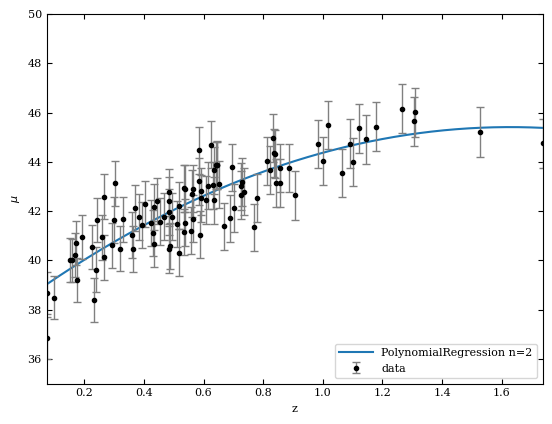

In [115]:
degree = best_ind_cv
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

print(model.coef_)

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50)